In [1]:
%pip install ucimlrepo tensorflow pandas numpy matplotlib scikit-learn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [3]:
digits = fetch_ucirepo(id=80)

X = digits.data.features
y = digits.data.targets.squeeze()

print('Dimensión de X:', X.shape)
print('Dimensión de y:', y.shape)

X.head()

Dimensión de X: (5620, 64)
Dimensión de y: (5620,)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0


In [4]:
print('Clases disponibles:', sorted(y.unique()))
print('\nDistribución de clases:')
print(y.value_counts().sort_index())

Clases disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Distribución de clases:
class
0    554
1    571
2    557
3    572
4    568
5    558
6    558
7    566
8    554
9    562
Name: count, dtype: int64


Convertir los datos a imágenes 8x8

In [5]:

X_images = X.to_numpy().reshape(-1, 8, 8, 1)
y_values = y.to_numpy().astype('int')

print('Nueva forma de X:', X_images.shape)
print('Forma de y:', y_values.shape)

Nueva forma de X: (5620, 8, 8, 1)
Forma de y: (5620,)


Visualizar ejemplos del dataset

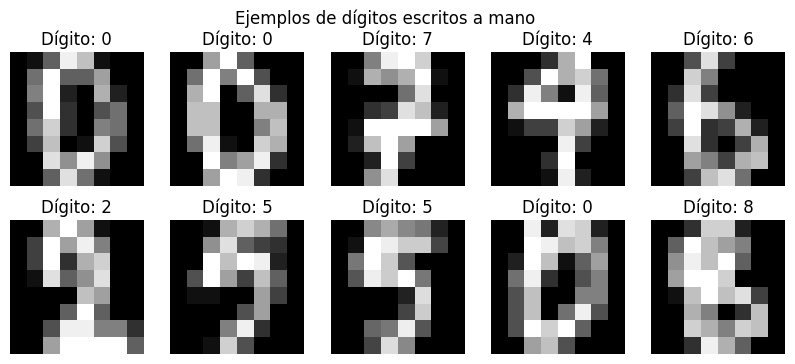

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_images[i].reshape(8, 8), cmap='gray')
    plt.title(f'Dígito: {y_values[i]}')
    plt.axis('off')

plt.suptitle('Ejemplos de dígitos escritos a mano')
plt.show()

Normalizacion

In [7]:
X_images = X_images / 16.0

print('Valor mínimo:', X_images.min())
print('Valor máximo:', X_images.max())

Valor mínimo: 0.0
Valor máximo: 1.0


Codificación de la variable objetivo

In [8]:
num_classes = 10
y_categorical = to_categorical(y_values, num_classes=num_classes)

print('Ejemplo etiqueta original:', y_values[0])
print('Ejemplo etiqueta one-hot:', y_categorical[0])

Ejemplo etiqueta original: 0
Ejemplo etiqueta one-hot: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


División entrenamiento / prueba

In [9]:
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_images,
    y_categorical,
    y_values,
    test_size=0.30,
    random_state=42,
    stratify=y_values,
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (3934, 8, 8, 1)
X_test: (1686, 8, 8, 1)
y_train: (3934, 10)
y_test: (1686, 10)


Construcción del modelo CNN

In [10]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,146 (43.54 KB)

 Trainable params: 11,146 (43.54 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del modelo

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4649 - loss: 1.8382 - val_accuracy: 0.7243 - val_loss: 1.0100
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8125 - loss: 0.6843 - val_accuracy: 0.9047 - val_loss: 0.3797
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8904 - loss: 0.3900 - val_accuracy: 0.9454 - val_loss: 0.2320
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9177 - loss: 0.2864 - val_accuracy: 0.9543 - val_loss: 0.1807
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9342 - loss: 0.2294 - val_accuracy: 0.9632 - val_loss: 0.1418
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9501 - loss: 0.1742 - val_accuracy: 0.9657 - val_loss: 0.1185
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9530 - loss: 0.1606 - val_accuracy: 0.9644 - val_loss: 0.1131
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9593 - loss: 0.1446 - val_accuracy: 0.9632 - val_loss:

Visualizar curvas de entrenamiento

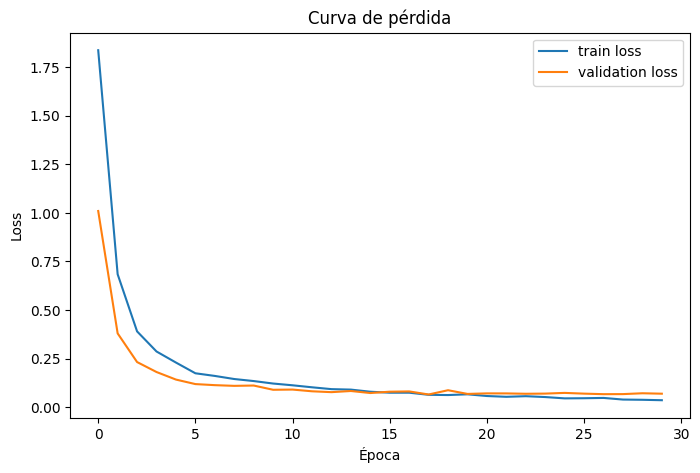

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

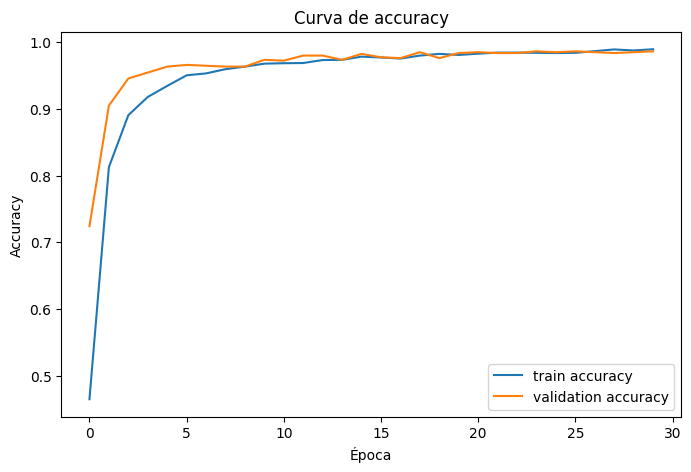

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

Evaluación en datos de prueba

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss    : 0.0553
Test accuracy: 0.9822


Reporte de clasificación

In [15]:
y_pred_prob = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_labels, y_pred_labels))

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       166
           1       1.00      0.99      0.99       171
           2       0.98      0.99      0.99       167
           3       0.98      0.95      0.96       172
           4       0.99      1.00      1.00       171
           5       0.97      0.98      0.97       167
           6       0.99      0.99      0.99       167
           7       0.97      1.00      0.98       170
           8       0.97      0.98      0.98       166
           9       0.97      0.96      0.96       169

    accuracy                           0.98      1686
   macro avg       0.98      0.98      0.98      1686
weighted avg       0.98      0.98      0.98      1686



Matriz de confusión

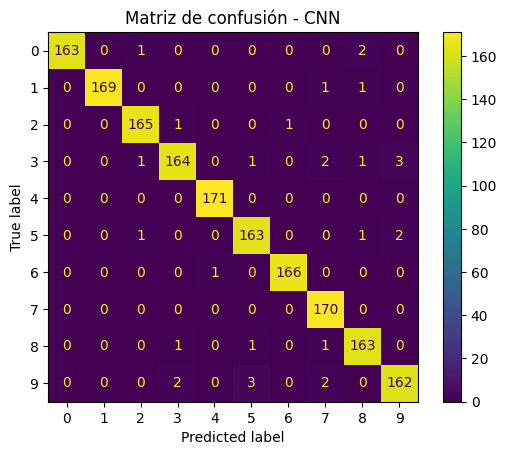

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels,
    display_labels=list(range(10)),
)
plt.title('Matriz de confusión - CNN')
plt.show()

Predicciones individuales

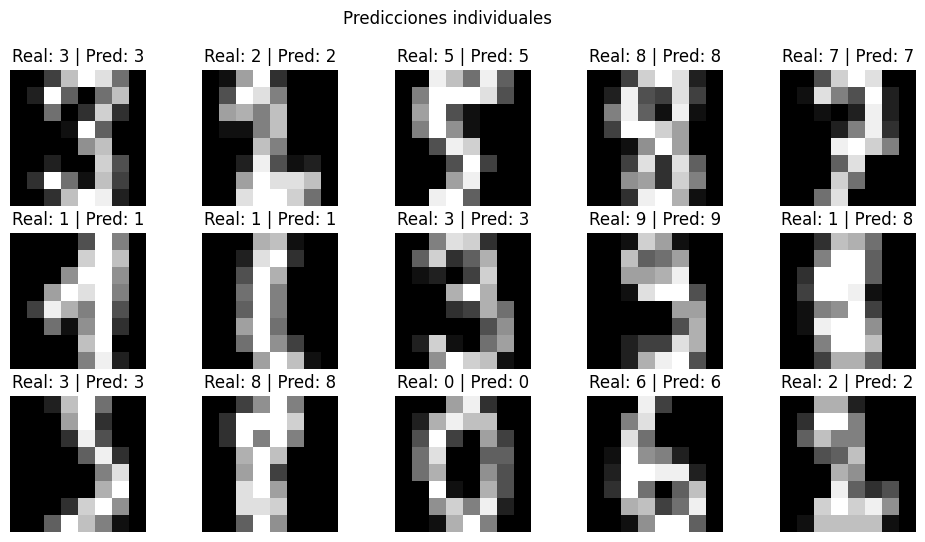

In [17]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[i]} | Pred: {y_pred_labels[i]}')
    plt.axis('off')

plt.suptitle('Predicciones individuales')
plt.show()

Visualizar errores del modelo

Cantidad de errores: 30


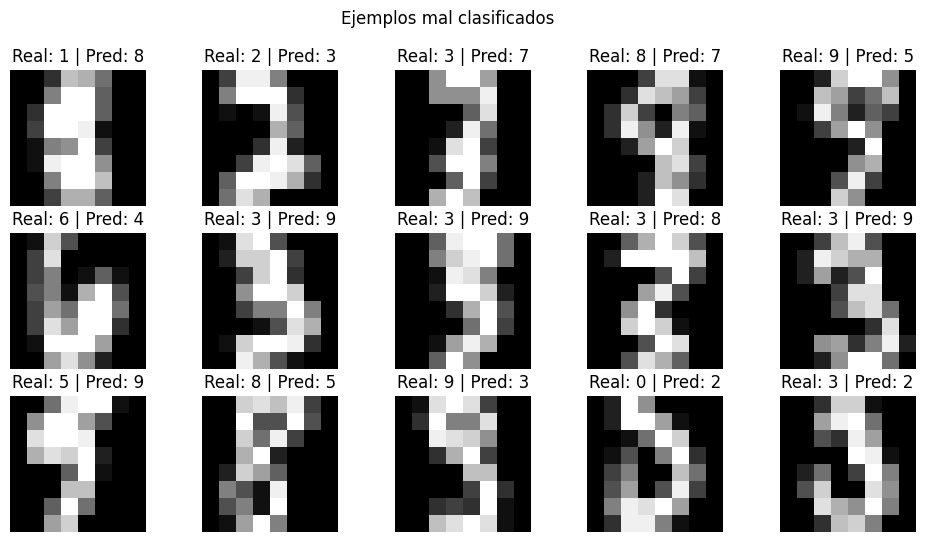

In [18]:
wrong_indices = np.where(y_test_labels != y_pred_labels)[0]

print('Cantidad de errores:', len(wrong_indices))

plt.figure(figsize=(12, 6))

for plot_index, data_index in enumerate(wrong_indices[:15]):
    plt.subplot(3, 5, plot_index + 1)
    plt.imshow(X_test[data_index].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[data_index]} | Pred: {y_pred_labels[data_index]}')
    plt.axis('off')

plt.suptitle('Ejemplos mal clasificados')
plt.show()

Comparación con una red densa simple

In [19]:
dense_model = Sequential([
    Flatten(input_shape=(8, 8, 1)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dense_history = dense_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

dense_loss, dense_accuracy = dense_model.evaluate(X_test, y_test, verbose=0)

print(f'Accuracy CNN        : {test_accuracy:.4f}')
print(f'Accuracy Dense Model: {dense_accuracy:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy CNN        : 0.9822
Accuracy Dense Model: 0.9745


Guardar el modelo

In [20]:
model.save('cnn_digits_uci.keras')
print('Modelo guardado como cnn_digits_uci.keras')

Modelo guardado como cnn_digits_uci.keras
